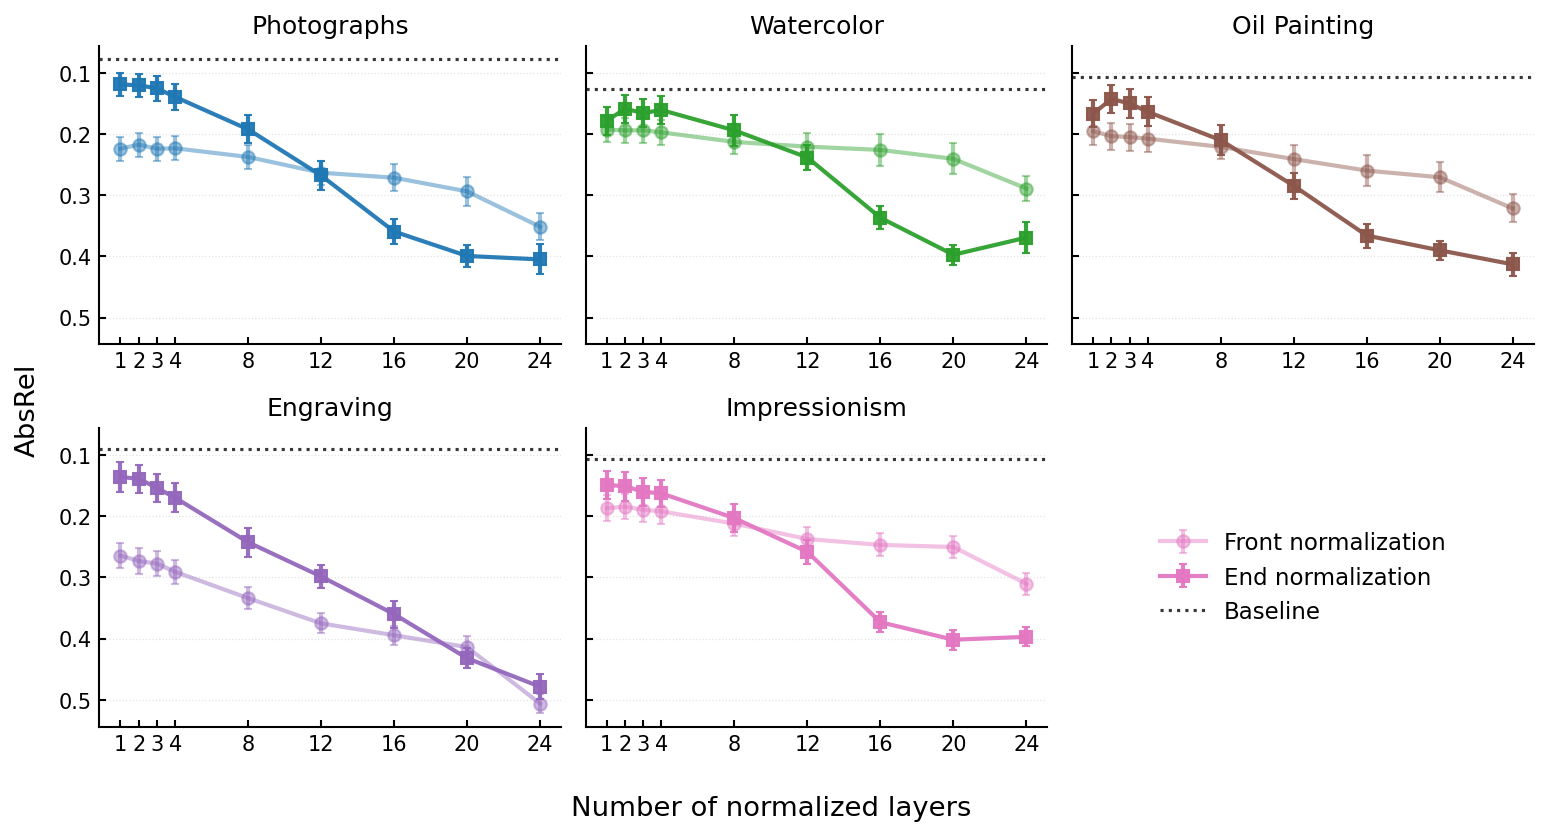

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Configuration
# --------------------------------------------------
RESULTS_DIR = Path("./evaluation_results")
CACHE_CSV_PATH = RESULTS_DIR / "norm_results.csv"

METRIC = "AbsRel"
STATISTIC = "MEDIAN"
BLOCKS_RANGE = [0, 1, 2, 3, 4, 8, 12, 16, 20, 24]
plot_blocks = BLOCKS_RANGE[1:]  # Exclude block 0 from trendlines

BASELINES = ["photographs", "watercolor", "oil_painting", "engraving", "impressionism"]

DISPLAY_NAMES = {
    "photographs": "Photographs",
    "watercolor": "Watercolor",
    "oil_painting": "Oil Painting",
    "engraving": "Engraving",
    "impressionism": "Impressionism"
}

STYLE_COLORS = {
    "photographs":   "#1F77B4",
    "watercolor":    "#2CA02C",
    "oil_painting":  "#8C564B",
    "engraving":     "#9467BD",
    "impressionism": "#E377C2"
}

SAVE_FIGURE = False
OUTPUT_NAME = f"normalization_subplots_{METRIC}_{STATISTIC}.pdf"

# Reverted to matplotlib's default sans-serif font
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
# --------------------------------------------------
# Load Data
# --------------------------------------------------
if not CACHE_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing processed cache frame at {CACHE_CSV_PATH}. Execute calculation cell first.")

df_cached = pd.read_csv(CACHE_CSV_PATH)

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.6), sharey=True)
axes = axes.flatten()

# --------------------------------------------------
# Plot each style
# --------------------------------------------------
for idx, baseline in enumerate(BASELINES):
    ax = axes[idx]
    
    # Filter global frame for current style mapping
    df_style = df_cached[df_cached["style"] == baseline].sort_values("blocks")
    
    # Baseline line calculation (corresponds to blocks == 0 value)
    baseline_value = df_style[df_style["blocks"] == 0]["front_value"].values[0]
    
    baseline_handle = ax.axhline(
        baseline_value,
        linestyle=":",
        linewidth=1.5,
        color="#222222",
        alpha=0.9,
        label="Baseline"
    )
    
    # Strip blocks context for linear visualization bounds [1:]
    df_trends = df_style[df_style["blocks"] > 0]
    color = STYLE_COLORS[baseline]

    # Front Normalization
    front_handle = ax.errorbar(
        df_trends["blocks"],
        df_trends["front_value"],
        yerr=df_trends["front_sem"],
        marker='o',
        linewidth=2,
        capsize=2,
        linestyle='-',
        alpha=0.45,
        color=color,
        label="Front"
    )

    # End Normalization
    end_handle = ax.errorbar(
        df_trends["blocks"],
        df_trends["end_value"],
        yerr=df_trends["end_sem"],
        marker='s',
        linewidth=2,
        capsize=2,
        linestyle='-',
        alpha=0.95,
        color=color,
        label="End"
    )

    # Formatting axis grids
    ax.set_title(DISPLAY_NAMES[baseline])
    ax.set_xticks(plot_blocks)
    ax.tick_params(axis='x', labelbottom=True)
    ax.set_xticklabels([str(x) for x in plot_blocks])
    
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# --------------------------------------------------
# Dedicated legend subplot
# --------------------------------------------------
legend_ax = axes[-1]
legend_ax.axis("off")
legend_ax.legend(
    handles=[front_handle, end_handle, baseline_handle],
    labels=["Front normalization", "End normalization", "Baseline"],
    loc="center",
    frameon=False,
    fontsize=11
)

# --------------------------------------------------
# Global labels and formatting parameters
# --------------------------------------------------
fig.supxlabel("Number of normalized layers")
fig.supylabel(METRIC)

for ax in axes[:-1]:  # exclude legend axis
    ax.invert_yaxis()
    
plt.tight_layout()

# --------------------------------------------------
# Save Target Output
# --------------------------------------------------
if SAVE_FIGURE:
    plt.savefig(OUTPUT_NAME, bbox_inches="tight", transparent=True)
    print(f"Saved to {OUTPUT_NAME}")

plt.show()